In [3]:
print('hello, world!')

hello, world!


In [4]:
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [6]:
# Normalize the pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

print(f"Normalized training images min: {train_images.min()}, max: {train_images.max()}")
print(f"Normalized test images min: {test_images.min()}, max: {test_images.max()}")

Normalized training images min: 0.0, max: 1.0
Normalized test images min: 0.0, max: 1.0


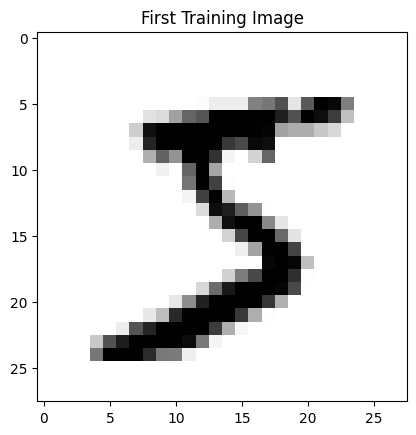

In [7]:
plt.imshow(train_images[0], cmap=plt.cm.binary)
plt.title("First Training Image")
plt.show()


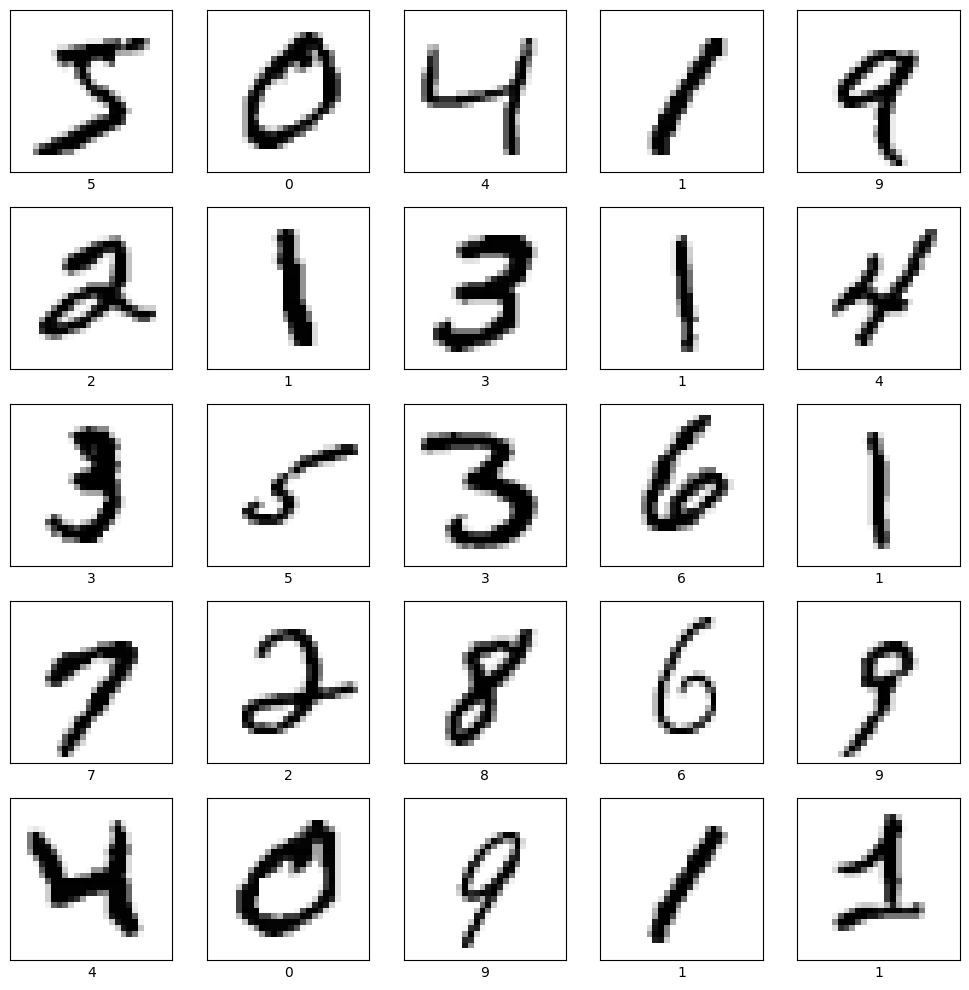

In [8]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(train_labels[i])
plt.tight_layout()
plt.show()

In [9]:
# Use 10000 images train, 5000 images test
train_images = train_images[:10000]
train_labels = train_labels[:10000]

In [10]:
test_images = test_images[:5000]
test_labels = test_labels[:5000]  

In [11]:
# Reshape images to 1D
train_images = train_images.reshape(train_images.shape[0], -1)
test_images = test_images.reshape(test_images.shape[0], -1)

print(f"Reshaped training images shape: {train_images.shape}")
print(f"Reshaped test images shape: {test_images.shape}")

Reshaped training images shape: (10000, 784)
Reshaped test images shape: (5000, 784)


In [12]:
# Convert labels to one-hot encoding
train_labels_one_hot = tf.keras.utils.to_categorical(train_labels, num_classes=10)
test_labels_one_hot = tf.keras.utils.to_categorical(test_labels, num_classes=10)

print(f"One-hot encoded training labels shape: {train_labels_one_hot.shape}")
print(f"One-hot encoded test labels shape: {test_labels_one_hot.shape}")

One-hot encoded training labels shape: (10000, 10)
One-hot encoded test labels shape: (5000, 10)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [14]:
model = Sequential()

In [15]:
input_shape = (784,)


In [16]:
model.add(Dense(100, activation='relu', input_shape=input_shape))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.add(Dense(100, activation='relu', input_shape=input_shape))

In [18]:
model.add(Dense(10, activation='softmax'))

In [19]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(train_images, train_labels_one_hot, validation_split=0.3, epochs=10, batch_size=32)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8304 - loss: 0.6110 - val_accuracy: 0.8920 - val_loss: 0.3617
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9303 - loss: 0.2365 - val_accuracy: 0.9167 - val_loss: 0.2916
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9506 - loss: 0.1668 - val_accuracy: 0.9240 - val_loss: 0.2657
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9649 - loss: 0.1178 - val_accuracy: 0.9273 - val_loss: 0.2479
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9724 - loss: 0.0912 - val_accuracy: 0.9253 - val_loss: 0.2464
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9837 - loss: 0.0616 - val_accuracy: 0.9360 - val_loss: 0.2380
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9887 - loss: 0.0447 - val_accuracy: 0.9340 - val_loss: 0.2496
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9924 - loss: 0.0326 - val_accuracy: 0.

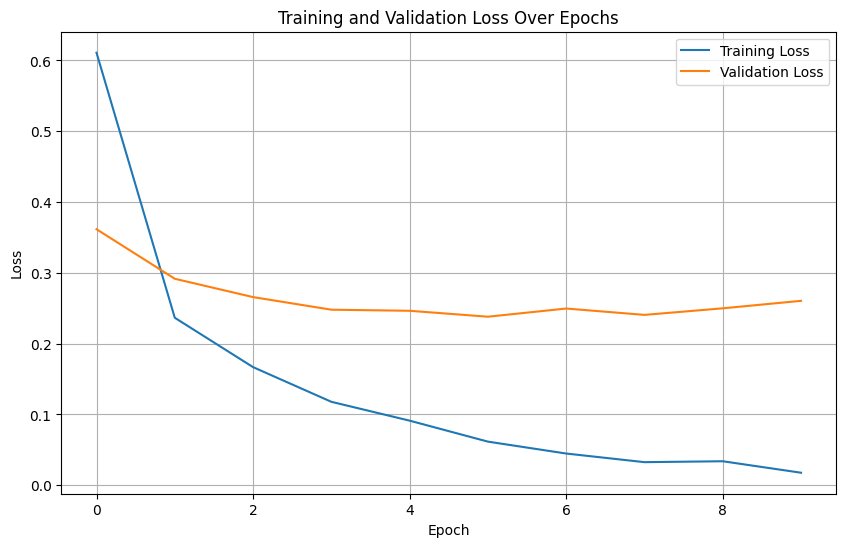

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()